In [7]:
import numpy as np
import pandas as pd

df = pd.read_csv('titanic.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn types:")
print(df.dtypes)

Shape: (891, 4)

First 5 rows:
  Cabin            Ticket number  Survived
0   NaN         A/5 21171      5         0
1   C85          PC 17599      3         1
2   NaN  STON/O2. 3101282      6         1
3  C123            113803      3         1
4   NaN            373450      A         0

Column types:
Cabin         str
Ticket        str
number        str
Survived    int64
dtype: object


In [8]:
print("Unique Values in number column :")
print(df['number'].unique())

Unique Values in number column :
<ArrowStringArray>
['5', '3', '6', 'A', '2', '1', '4']
Length: 7, dtype: str


Text(0.5, 1.0, 'Passengers trvelling with family or alone')

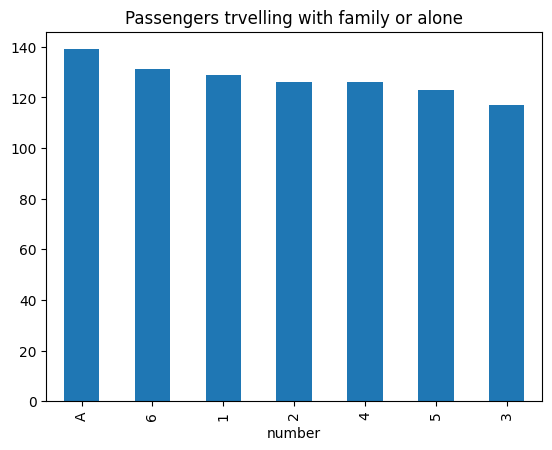

In [6]:
fig = df['number'].value_counts().plot.bar()
fig.set_title('Passengers trvelling with family or alone')

In [9]:
# STEP 1: extract numerical part
# pd.to_numeric → converts string to number
# errors='coerce' → if conversion fails (like 'A') → put NaN instead of error
# downcast='integer' → store as integer not float where possible

df['number_numerical'] = pd.to_numeric(
    df['number'],
    errors='coerce',      # 'A' → NaN (can't convert)
    downcast='integer'    # '5' → 5 (integer)
)

print("number_numerical sample:")
print(df[['number','number_numerical']].head(10))

number_numerical sample:
  number  number_numerical
0      5               5.0
1      3               3.0
2      6               6.0
3      3               3.0
4      A               NaN
5      2               2.0
6      2               2.0
7      5               5.0
8      1               1.0
9      A               NaN


In [10]:
# STEP 2: extract categorical part
# np.where(condition, value_if_true, value_if_false)
# condition  → number_numerical is NaN (meaning original was a letter)
# if true    → keep original number value (the letter like 'A')
# if false   → put NaN (it was a digit, already captured above)

df['number_categorical'] = np.where(
    df['number_numerical'].isnull(),   # where number_numerical is NaN
    df['number'],                       # keep original (it's a letter like 'A')
    np.nan                              # else put NaN (it's a digit)
)

print("\nAll three columns side by side:")
print(df[['number','number_numerical','number_categorical']].head(10))


All three columns side by side:
  number  number_numerical number_categorical
0      5               5.0                NaN
1      3               3.0                NaN
2      6               6.0                NaN
3      3               3.0                NaN
4      A               NaN                  A
5      2               2.0                NaN
6      2               2.0                NaN
7      5               5.0                NaN
8      1               1.0                NaN
9      A               NaN                  A


In [11]:
print("Unique cabin values:")
print(df['Cabin'].unique()[:10])

Unique cabin values:
<ArrowStringArray>
[nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6', 'C23 C25 C27', 'B78']
Length: 10, dtype: str


In [14]:
# STEP 1: extract number from cabin
# str.extract('(\d+)') → regex that finds digits
# \d  → means "any digit"
# +   → means "one or more"
# ()  → captures what's inside

df['cabin_num'] = df['Cabin'].str.extract('(\d+)')
df['cabin_num'] = df['cabin_num'].fillna(0)
print("cabin_num sample:")
print(df[['Cabin','cabin_num']].head(10))

cabin_num sample:
  Cabin cabin_num
0   NaN         0
1   C85        85
2   NaN         0
3  C123       123
4   NaN         0
5   NaN         0
6   E46        46
7   NaN         0
8   NaN         0
9   NaN         0


<>:7: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:7: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\kinar\AppData\Local\Temp\ipykernel_14912\2165244195.py:7: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df['cabin_num'] = df['Cabin'].str.extract('(\d+)')



cabin_cat sample:
  Cabin cabin_num cabin_cat
0   NaN         0       NaN
1   C85        85         C
2   NaN         0       NaN
3  C123       123         C
4   NaN         0       NaN
5   NaN         0       NaN
6   E46        46         E
7   NaN         0       NaN
8   NaN         0       NaN
9   NaN         0       NaN

Cabin deck distribution:
cabin_cat
C    59
B    47
D    33
E    32
A    15
F    13
G     4
T     1
Name: count, dtype: int64


<Axes: xlabel='cabin_cat'>

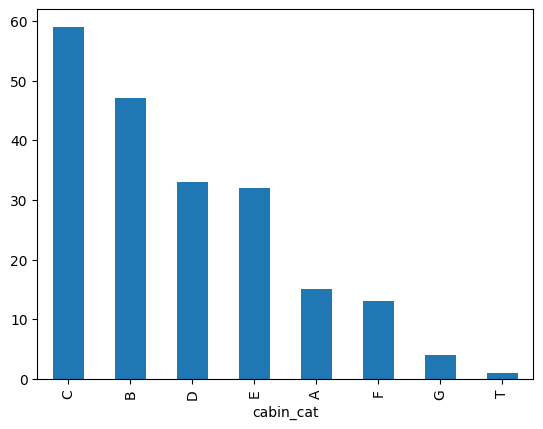

In [15]:
# STEP 2: extract letter (deck) from cabin
# str[0] → gets FIRST character of the string
# C85  → C
# E46  → E
# NaN  → NaN (missing stays missing)

df['cabin_cat'] = df['Cabin'].str[0]

print("\ncabin_cat sample:")
print(df[['Cabin','cabin_num','cabin_cat']].head(10))

print("\nCabin deck distribution:")
print(df['cabin_cat'].value_counts())

# visualize deck distribution
df['cabin_cat'].value_counts().plot(kind='bar')

In [17]:
print("Sample ticket values:")
print(df['Ticket'].unique())

Sample ticket values:
<ArrowStringArray>
[       'A/5 21171',         'PC 17599', 'STON/O2. 3101282',
           '113803',           '373450',           '330877',
            '17463',           '349909',           '347742',
           '237736',
 ...
           '349212',           '349217',           '349257',
             '7552', 'C.A./SOTON 34068',  'SOTON/OQ 392076',
           '211536',           '112053',           '111369',
           '370376']
Length: 681, dtype: str


In [18]:
# STEP 1: extract ticket number (last part after split)
# s.split()    → splits string by space into list
#               "PC 17599"  → ['PC', '17599']
#               "113803"    → ['113803']
# [-1]         → takes the LAST element
#               ['PC', '17599'][-1] → '17599'
#               ['113803'][-1]      → '113803'
# lambda s:    → anonymous function applied to each row

df['ticket_num'] = df['Ticket'].apply(lambda s: s.split()[-1])

# convert to number
# errors='coerce' → if can't convert → NaN
df['ticket_num'] = pd.to_numeric(
    df['ticket_num'],
    errors='coerce',
    downcast='integer'
)

print("ticket_num sample:")
print(df[['Ticket','ticket_num']].head(10))


ticket_num sample:
             Ticket  ticket_num
0         A/5 21171     21171.0
1          PC 17599     17599.0
2  STON/O2. 3101282   3101282.0
3            113803    113803.0
4            373450    373450.0
5            330877    330877.0
6             17463     17463.0
7            349909    349909.0
8            347742    347742.0
9            237736    237736.0


In [19]:
# STEP 2: extract ticket prefix (first part)
# s.split()[0]  → takes the FIRST element after split
#               "PC 17599"  → ['PC', '17599'][0] → 'PC'
#               "113803"    → ['113803'][0]       → '113803'

df['ticket_cat'] = df['Ticket'].apply(lambda s: s.split()[0])

# if first part is a digit → it's a number-only ticket → no prefix → NaN
# str.isdigit() → returns True if all characters are digits
# np.where:
#   if ticket_cat is ALL digits → no prefix → NaN
#   else                        → it IS a prefix → keep it

df['ticket_cat'] = np.where(
    df['ticket_cat'].str.isdigit(),   # is it a pure number?
    np.nan,                            # yes → no prefix → NaN
    df['ticket_cat']                   # no  → it's a prefix → keep
)

print("ticket_cat sample:")
print(df[['Ticket','ticket_num','ticket_cat']].head(10))

print("\nUnique ticket prefixes:")
print(df['ticket_cat'].unique())

ticket_cat sample:
             Ticket  ticket_num ticket_cat
0         A/5 21171     21171.0        A/5
1          PC 17599     17599.0         PC
2  STON/O2. 3101282   3101282.0   STON/O2.
3            113803    113803.0        NaN
4            373450    373450.0        NaN
5            330877    330877.0        NaN
6             17463     17463.0        NaN
7            349909    349909.0        NaN
8            347742    347742.0        NaN
9            237736    237736.0        NaN

Unique ticket prefixes:
<ArrowStringArray>
[       'A/5',         'PC',   'STON/O2.',          nan,         'PP',
       'A/5.',       'C.A.',      'A./5.',   'SC/Paris',  'S.C./A.4.',
       'A/4.',         'CA',       'S.P.',     'S.O.C.',       'SO/C',
      'W./C.',   'SOTON/OQ',     'W.E.P.',     'STON/O',        'A4.',
          'C', 'SOTON/O.Q.',   'SC/PARIS',     'S.O.P.',       'A.5.',
         'Fa',        'CA.',       'LINE',     'F.C.C.',        'W/C',
      'SW/PP',      'SCO/W',       'P/

In [20]:
print("Final DataFrame:")
print(df.head(10).to_string())

print("\nNew columns created:")
print(df[['number_numerical','number_categorical',
          'cabin_num','cabin_cat',
          'ticket_num','ticket_cat']].head(10).to_string())

Final DataFrame:
  Cabin            Ticket number  Survived  number_numerical number_categorical cabin_num cabin_cat  ticket_num ticket_cat
0   NaN         A/5 21171      5         0               5.0                NaN         0       NaN     21171.0        A/5
1   C85          PC 17599      3         1               3.0                NaN        85         C     17599.0         PC
2   NaN  STON/O2. 3101282      6         1               6.0                NaN         0       NaN   3101282.0   STON/O2.
3  C123            113803      3         1               3.0                NaN       123         C    113803.0        NaN
4   NaN            373450      A         0               NaN                  A         0       NaN    373450.0        NaN
5   NaN            330877      2         0               2.0                NaN         0       NaN    330877.0        NaN
6   E46             17463      2         0               2.0                NaN        46         E     17463.0        NaN